In [24]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [25]:
# Download latest version
path = kagglehub.dataset_download("ayeshaimran123/social-media-and-mental-health-balance")

print(os.listdir(path))

['Mental_Health_and_Social_Media_Balance_Dataset.csv']


In [26]:
csv_path = os.path.join(path, "Mental_Health_and_Social_Media_Balance_Dataset.csv")

df = pd.read_csv(csv_path)
df

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0
...,...,...,...,...,...,...,...,...,...,...
495,U496,23,Male,6.9,5.0,7.0,4.0,2.0,X (Twitter),10.0
496,U497,43,Female,5.6,7.0,6.0,5.0,2.0,Facebook,9.0
497,U498,41,Male,7.7,5.0,7.0,2.0,2.0,LinkedIn,8.0
498,U499,23,Male,4.2,9.0,7.0,0.0,2.0,Facebook,9.0


In [27]:
# Explore the dataset
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    500 non-null    object 
 1   Age                        500 non-null    int64  
 2   Gender                     500 non-null    object 
 3   Daily_Screen_Time(hrs)     500 non-null    float64
 4   Sleep_Quality(1-10)        500 non-null    float64
 5   Stress_Level(1-10)         500 non-null    float64
 6   Days_Without_Social_Media  500 non-null    float64
 7   Exercise_Frequency(week)   500 non-null    float64
 8   Social_Media_Platform      500 non-null    object 
 9   Happiness_Index(1-10)      500 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB


User_ID                      0
Age                          0
Gender                       0
Daily_Screen_Time(hrs)       0
Sleep_Quality(1-10)          0
Stress_Level(1-10)           0
Days_Without_Social_Media    0
Exercise_Frequency(week)     0
Social_Media_Platform        0
Happiness_Index(1-10)        0
dtype: int64

In [28]:
# drop user_id column as it is not useful for prediction
df = df.drop(columns=['User_ID'])

In [29]:
# define features and target variable
features = df.drop("Happiness_Index(1-10)", axis=1)
target = df["Happiness_Index(1-10)"]

In [30]:
# Preprocess categorical variables
categorical_features = features.select_dtypes(include=['object']).columns
numerical_features = features.select_dtypes(include=['int64', 'float64']).columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

In [31]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [32]:
# create a pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [33]:
# fit the model
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
# make predictions
y_pred = pipeline.predict(X_test)

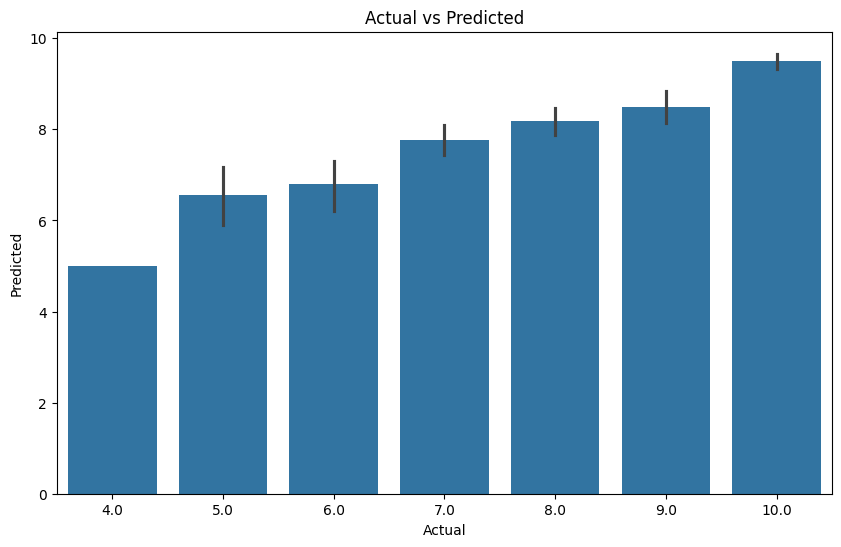

In [39]:
# plot actual vs predicted
plt.figure(figsize=(10,6))
sns.barplot(x=y_test, y=y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [36]:
#evaluate the model using R squared and Mean Squared Error
r2 = pipeline.score(X_test, y_test)
mse = mean_squared_error(y_test, y_pred)
print(f"R squared: {r2}")
print(f"Mean Squared Error: {mse}")

R squared: 0.6447933153729585
Mean Squared Error: 0.8438289999999999


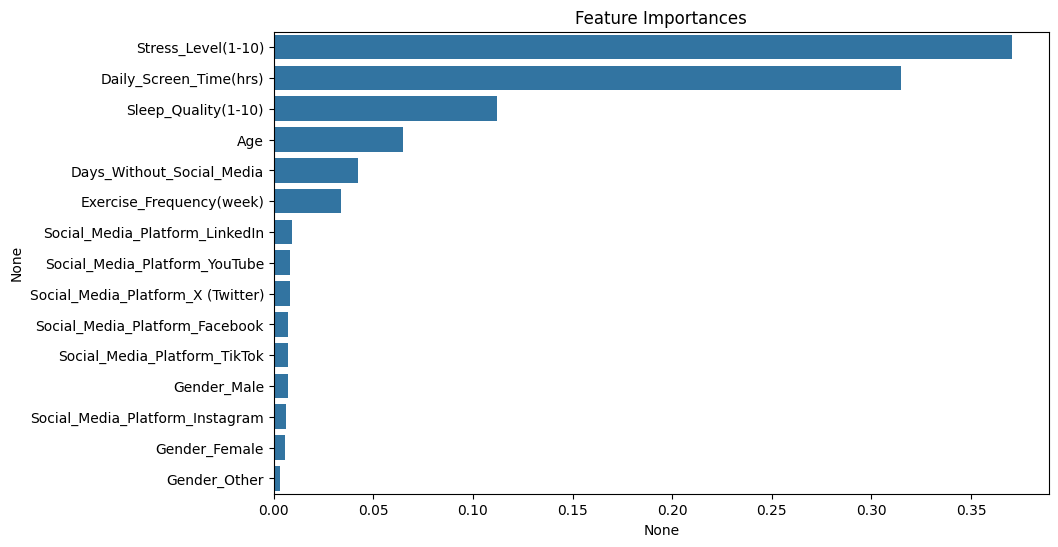

In [37]:
# feature importance
importances = pipeline.named_steps['regressor'].feature_importances_
feature_names = numerical_features.tolist() + list(pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features))
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importances")
plt.show()

In [40]:
# rebuild the model using only the most important features
important_features = feature_importances[feature_importances > 0.05].index.tolist()
X_train_important = X_train[important_features]
X_test_important = X_test[important_features]
pipeline_important = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), [col for col in important_features if col in numerical_features]),
            ('cat', OneHotEncoder(), [col for col in important_features if col in categorical_features])
        ])),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
pipeline_important.fit(X_train_important, y_train)
y_pred_important = pipeline_important.predict(X_test_important)
r2_important = pipeline_important.score(X_test_important, y_test)
mse_important = mean_squared_error(y_test, y_pred_important)
print(f"R squared (important features): {r2_important}")
print(f"Mean Squared Error (important features): {mse_important}")

R squared (important features): 0.6098110788385624
Mean Squared Error (important features): 0.9269328011111111
